# Code Review - DQN
교재 : 딥러닝 파이토치 교과서  
범위 : 12.4.2장 Deep Q-learning


## Import

In [79]:
import gym  # 강화 학습 환경을 쉽게 구성하도록 도와주는 파이썬 패키지
import math
import random
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple  # 키 값으로도 데이터에 접근 가능한 튜플 자료형
from itertools import count
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as T

# CartPole 환경 생성: 카트를 우로 이동시켜 카트 위의 막대를 수직으로 유지하는 것이 목표
env = gym.make("CartPole-v1", render_mode='single_rgb_array')
plt.ion() # matplotlib interactive 모드 활성화
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/gym/core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
/usr/local/lib/python3.12/dist-packages/gym/wrappers/step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(


In [72]:
# 한글 깨짐 방지

!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] =False

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

## Model

**Model class**

In [80]:
# Transition: 상태 전이 정보를 저장하는 namedtuple
# 현재 상태(state)에서 행동(action)을 하면 보상(reward)을 받고 다음 상태(next_state)로 이동
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))

# ReplayMemory: 에이전트가 관찰한 상태 전이를 저장하는 리플레이 메모리
# 저장된 데이터를 나중에 랜덤 샘플링하여 학습에 재사용 -> 샘플 간 상관관계를 줄여 학습 안정성 향상
class ReplayMemory(object):
    def __init__(self, capacity):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args): # 새로운 상태 전이를 메모리에 저장
        if len(self.memory) < self.capacity:
            self.memory.append(None) # 메모리가 가득 차지 않았으면 공간 추가
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity # 다음 위치로 이동 (가득 차면 처음부터 덮어씀)

    def sample(self, batch_size): # 메모리에 저장된 데이터 중 배치 크기만큼 랜덤 샘플링
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [69]:
# DQN 모델: CartPole 화면(이미지)을 입력받아 각 행동의 Q값을 예측하는 CNN
# 학습 목표 - 누적 보상이 최대가 되도록 네트워크 학습
class DQN(nn.Module):
    def __init__(self, h, w, outputs):
        # 3개의 Conv + BatchNorm 블록으로 특징 추출
        super(DQN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=5, stride=2)
        self.bn1 = nn.BatchNorm2d(16)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, stride=2)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 32, kernel_size=5, stride=2)
        self.bn3 = nn.BatchNorm2d(32)

        def conv2d_size_out(size, kernel_size = 5, stride = 2): # 선형 계층의 입력 크기는 합성곱층의 출력과 입력 이미지 크기에 따라 달라지므로 계산 필요
            return (size - (kernel_size - 1) - 1) // stride  + 1

        # 너비와 높이에 대해 conv 3번 통과 후의 크기 계산
        convw = conv2d_size_out(conv2d_size_out(conv2d_size_out(w)))
        convh = conv2d_size_out(conv2d_size_out(conv2d_size_out(h)))
        linear_input_size = convw * convh * 32  # flatten 후 크기 = 너비 x 높이 x 채널 수
        self.head = nn.Linear(linear_input_size, outputs) # 최종적으로 각 행동의 Q값 출력

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        return self.head(x.view(x.size(0), -1))

In [65]:
!pip install pyglet

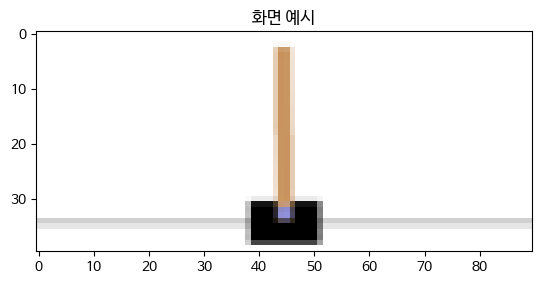

In [81]:
# 환경에서 이미지 추출 및 처리
import pyglet

# 이미지 크기 변경 및 텐서 변환
resize = T.Compose([T.ToPILImage(),
                    T.Resize(40, interpolation=Image.BICUBIC),
                    T.ToTensor()])

def get_cart_location(screen_width): # 카트의 현재 위치(중앙)를 반환
    world_width = env.x_threshold * 2
    scale = screen_width / world_width  # 월드 좌표 -> 픽셀 좌표 변환 스케일
    return int(env.state[0] * scale + screen_width / 2.0)

def get_screen(): # gym 환경의 현재 화면을 가져와 전처리 후 텐서로 반환
    screen = env.render().transpose((2, 0, 1)) # env.render()는 (H, W, C) 형태의 배열 반환 -> (C, H, W)로 transpose
    _, screen_height, screen_width = screen.shape
    screen = screen[:, int(screen_height*0.4):int(screen_height * 0.8)] # 화면의 위쪽과 아래쪽 제거
    view_width = int(screen_width * 0.6) # 좌우로 자를 폭
    cart_location = get_cart_location(screen_width)

    # 카트가 화면 중앙에 오도록 좌우 자르기 범위 결정
    if cart_location < view_width // 2:                     # 카트가 화면 왼쪽에 치우친 경우: 왼쪽부터 view_width만큼
        slice_range = slice(view_width)
    elif cart_location > (screen_width - view_width // 2):  # 카트가 화면 오른쪽에 치우친 경우: 오른쪽부터 view_width만큼
        slice_range = slice(-view_width, None)
    else:                                                   # 카트가 중앙에 있는 경우: 카트를 중심으로 좌우 대칭
        slice_range = slice(cart_location - view_width // 2,
                            cart_location + view_width // 2)
    screen = screen[:, :, slice_range]

    screen = np.ascontiguousarray(screen, dtype=np.float32) / 255  # 메모리에 연속적으로 저장된 배열로 변환 & [0, 1] 범위로 정규화
    screen = torch.from_numpy(screen)
    return resize(screen).unsqueeze(0).to(device)

env.reset()
plt.figure()
plt.imshow(get_screen().cpu().squeeze(0).permute(1, 2, 0).numpy(), # (C, H, W) -> (H, W, C)
           interpolation='none')
plt.title('화면 예시')
plt.show()

# Train

**Define model**

In [82]:
BATCH_SIZE = 128
GAMMA = 0.999       # 할인율
EPS_START = 0.9     # 탐험 확률 초기값
EPS_END = 0.05      # 탐험 확률 최소값
EPS_DECAY = 200     # 탐험 확률 감소율 제어

TARGET_UPDATE = 10  # 타깃 네트워크 업데이트 주기
init_screen = get_screen()
_, _, screen_height, screen_width = init_screen.shape
n_actions = env.action_space.n

# 정책 네트워크와 타깃 네트워크 생성
policy_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net = DQN(screen_height, screen_width, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict()) # policy_net의 가중치를 target_net으로 복사
target_net.eval() # 타깃 네트워크는 평가 모드

optimizer = optim.RMSprop(policy_net.parameters())
memory = ReplayMemory(10000)

steps_done = 0

# Epsilon-greedy policy에 따라 행동 선택 - 모델을 예측값을 사용하는 활용(exploitation) 혹은 리플레이 메모리에서 랜덤 샘플링하는 탐험(exploration)을 확률적으로 선택
def select_action(state):
    global steps_done
    sample = random.random()
    # Epsilon은 EPS_START에서 시작해 EPS_END를 향해 감소
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold: # 활용: 정책 네트워크가 예측한 Q값이 가장 큰 행동 선택
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else: # 탐험: 랜덤하게 행동 선택
        return torch.tensor([[random.randrange(n_actions)]], device=device, dtype=torch.long)

episode_durations = []

In [83]:
# 모델 학습 함수
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return

    # 리플레이 메모리에서 배치 크기만큼 샘플링
    transitions = memory.sample(BATCH_SIZE)
    batch = Transition(*zip(*transitions)) # zip(*transitions)으로 transition의 행과 열을 바꿈

    # 게임이 종료되지 않은 상태를 계산하기 위한 마스크
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None, # next_state가 None이 아닌 상태
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Q(s_t, a_t): 현재 상태에서 선택한 행동의 Q값 계산
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # V(s_{t+1}): 다음 상태의 가치 계산 (타깃 네트워크 사용)
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    next_state_values[non_final_mask] = target_net(non_final_next_states).max(1)[0].detach()
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # 손실 계산: smooth_l1_loss는 L1과 L2 손실의 장점을 결합한 함수
    loss = F.smooth_l1_loss(state_action_values, expected_state_action_values.unsqueeze(1))
    optimizer.zero_grad()
    loss.backward()

    for param in policy_net.parameters():
        param.grad.data.clamp_(-1, 1)
    optimizer.step()

**Train**

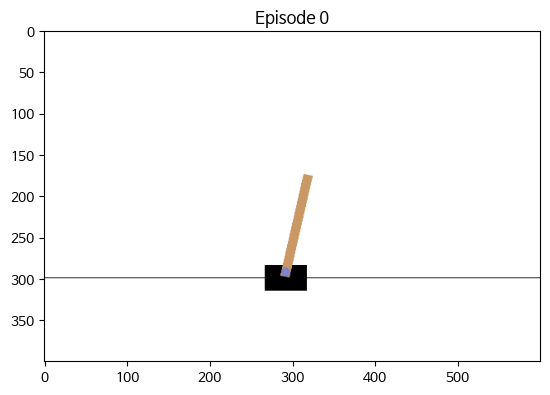

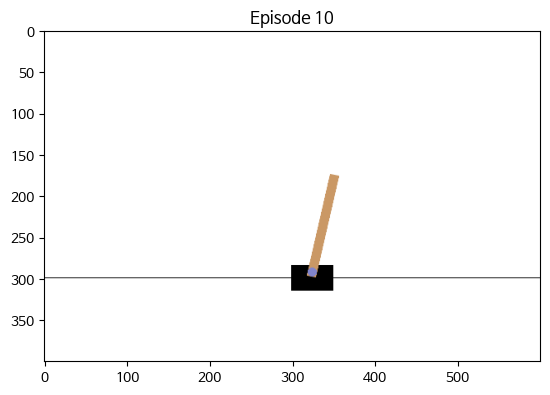

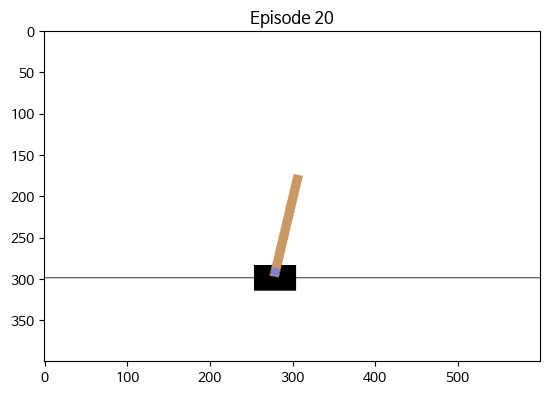

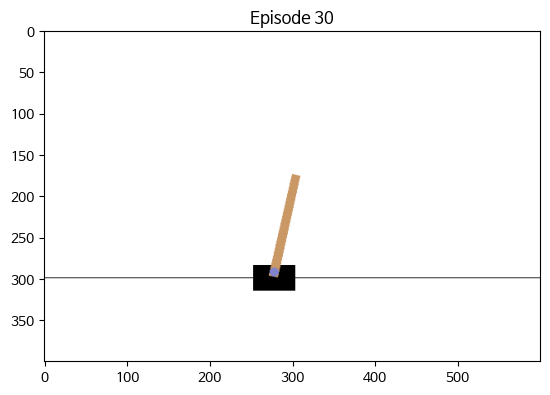

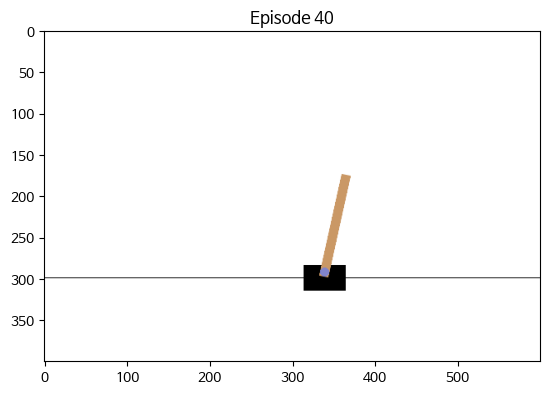

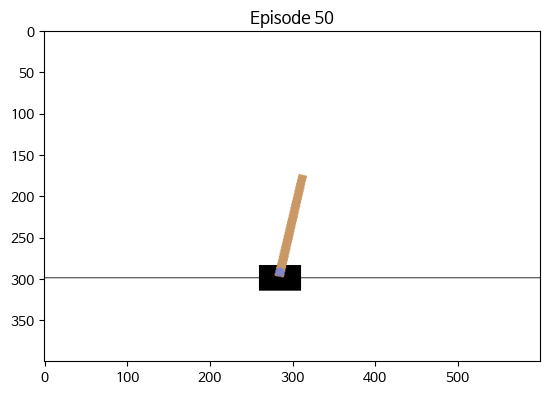

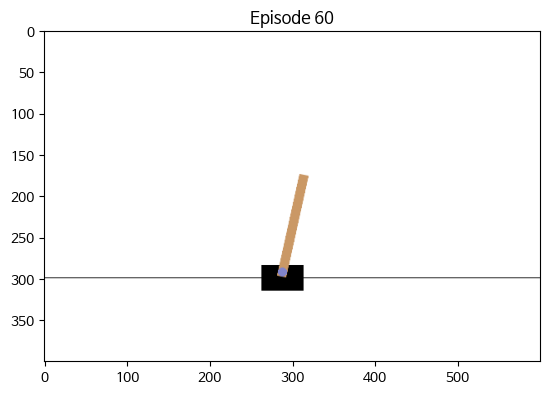

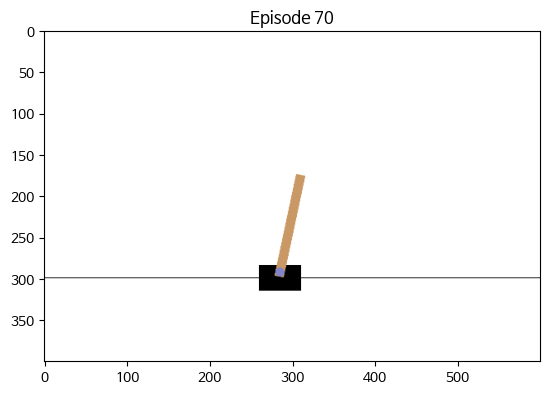

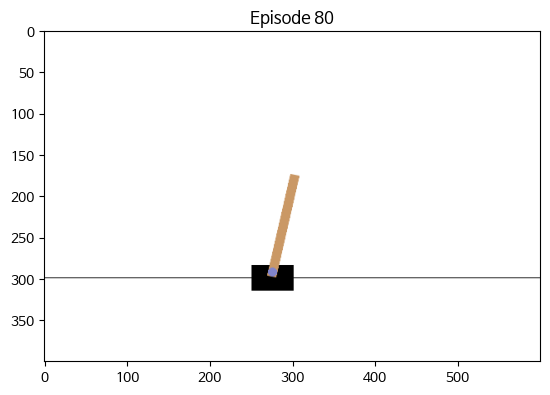

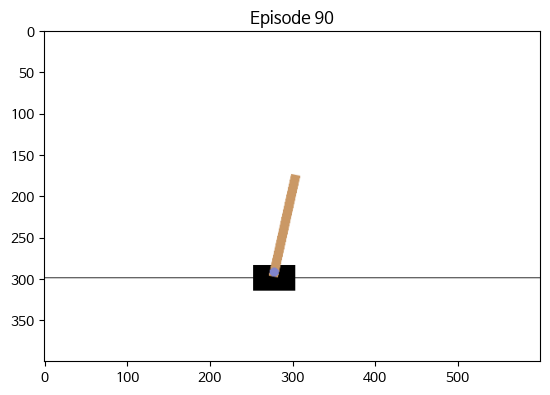

종료


In [89]:
num_episodes = 100  # 학습 에피소드 수

for i_episode in range(num_episodes):
    env.reset()  # 환경과 상태 초기화
    last_screen = get_screen()
    current_screen = get_screen()
    state = current_screen - last_screen

    for t in count():
        action = select_action(state)  # 행동 선택 및 실행
        _, reward, done, _ = env.step(action.item())  # 선택한 행동을 환경으로 보내고 결과 받기

        reward = torch.tensor([reward], device=device)

        last_screen = current_screen
        current_screen = get_screen()

        if not done:
            next_state = current_screen - last_screen  # 새로운 상태 관찰
        else:
            next_state = None  # 게임 종료 시 다음 상태 없음

        # 상태 전이(state transition)를 리플레이 메모리에 저장
        memory.push(state, action, next_state, reward)
        state = next_state  # 다음 상태로 이동

        # 정책 네트워크에 대해 최적화 진행
        optimize_model()
        if done:
            episode_durations.append(t + 1)
            break

    # TARGET_UPDATE 주기마다 정책 네트워크의 가중치를 타깃 네트워크로 복사 & 화면 시각화
    if i_episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

        plt.figure()
        plt.imshow(env.render() if not isinstance(env.render(), list) else env.render()[-1])
        plt.title(f'Episode {i_episode}')
        plt.show()

print('종료')
env.close()